## 1. Imports e ambiente


In [16]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os, shutil
import random
from sklearn.metrics import confusion_matrix, classification_report

## 2. Download do Dataset Oxford Pets

In [6]:
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz

!tar -xzf images.tar.gz
!tar -xzf annotations.tar.gz


--2025-12-06 20:13:57--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2025-12-06 20:13:57--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz.1’

images.tar.gz.1     100%[===================>] 755.23M  22.2MB/s    in 34s     

2025-12-06 20:14:32 (22.5 MB/s) - ‘images.tar.gz.1’ saved [791918971/791918971]

--2025-12-06 20:14:32--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Resolving w

## 3. Preparar estrutura de diretórios

In [8]:
# Criando Estrutura
base_dir = "data"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")

for d in [train_dir, val_dir]:
    os.makedirs(os.path.join(d, "cats"), exist_ok=True)
    os.makedirs(os.path.join(d, "dogs"), exist_ok=True)


In [11]:
# Base de gatos
CAT_BREEDS = [
    "abyssinian", "bengal", "birman", "bombay", "british_shorthair",
    "egyptian_mau", "maine_coon", "persian", "ragdoll", "russian_blue",
    "siamese", "sphynx"
]

# Base de cachorros
DOG_BREEDS = [
    "american_bulldog", "american_pit_bull_terrier", "basset_hound", "beagle", "boxer",
    "chihuahua", "english_cocker_spaniel", "english_setter", "german_shorthaired",
    "great_pyrenees", "havanese", "japanese_chin", "keeshond", "leonberger",
    "miniature_pinscher", "newfoundland", "pomeranian", "pug", "saint_bernard",
    "samoyed", "scottish_terrier", "shiba_inu", "staffordshire_bull_terrier",
    "wheaten_terrier", "yorkshire_terrier"
]


In [13]:
# Extrair nome de arquivos
def get_breed(filename):
    name = filename.lower()
    breed = "_".join(name.split("_")[:-1])  # remove o número final
    return breed


In [14]:
# Rotular cat/dog
def get_label(filename):
    breed = get_breed(filename)
    if breed in CAT_BREEDS:
        return "cat"
    elif breed in DOG_BREEDS:
        return "dog"
    else:
        return None


In [18]:
# Ler todos os arquivos e criar o split
images = os.listdir("images")
random.shuffle(images)

# split 80 / 20
split = int(len(images) * 0.8)
train_files = images[:split]
val_files = images[split:]


In [21]:
# Copiar os arquivos para suas pastas

## Treino
for fname in train_files:
    label = get_label(fname)
    if label is None:
        continue  # raça desconhecida = pula

    src = os.path.join("images", fname)
    dst = os.path.join(train_dir, label + "s", fname)  # cats/dogs

    shutil.copy(src, dst)

## Teste
for fname in val_files:
    label = get_label(fname)
    if label is None:
        continue

    src = os.path.join("images", fname)
    dst = os.path.join(val_dir, label + "s", fname)

    shutil.copy(src, dst)


In [22]:
# Validação
print("Treino cats:", len(os.listdir(os.path.join(train_dir, "cats"))))
print("Treino dogs:", len(os.listdir(os.path.join(train_dir, "dogs"))))
print("Val cats:", len(os.listdir(os.path.join(val_dir, "cats"))))
print("Val dogs:", len(os.listdir(os.path.join(val_dir, "dogs"))))


Treino cats: 1934
Treino dogs: 3980
Val cats: 469
Val dogs: 1010


## 4. Data Augmentation

In [23]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary"
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary"
)


Found 5911 images belonging to 2 classes.
Found 1479 images belonging to 2 classes.


## 5. Modelo com Transfer Learning (MobileNetV2)

In [24]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Treinamento

In [25]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 367s 2s/step - accuracy: 0.8901 - loss: 0.2673 - val_accuracy: 0.9838 - val_loss: 0.0637
Epoch 2/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.9820 - loss: 0.0643 - val_accuracy: 0.9865 - val_loss: 0.0467
Epoch 3/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.9851 - loss: 0.0478 - val_accuracy: 0.9804 - val_loss: 0.0450
Epoch 4/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 351s 2s/step - accuracy: 0.9877 - loss: 0.0388 - val_accuracy: 0.9899 - val_loss: 0.0355
Epoch 5/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 357s 2s/step - accuracy: 0.9859 - loss: 0.0385 - val_accuracy: 0.9905 - val_loss: 0.0324
Epoch 6/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - accuracy: 0.9870 - loss: 0.0332 - val_accuracy: 0.9885 - val_loss: 0.0331
Epoch 7/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - accuracy: 0.9852 - loss: 0.0365 - val_accuracy: 0.9899 - val_loss: 0.0306
Epoch 8/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.9886 - loss: 0.0351 - val_accu

## 7. Gráficos

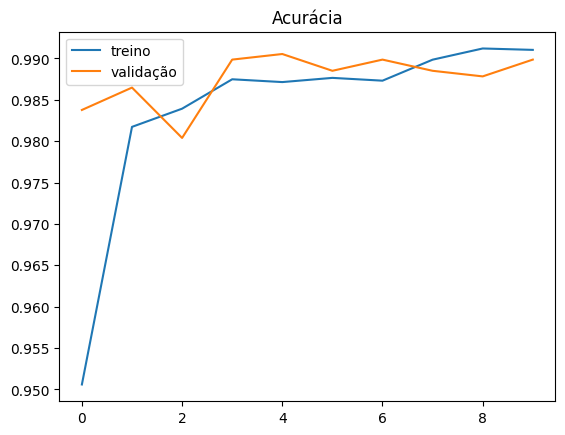

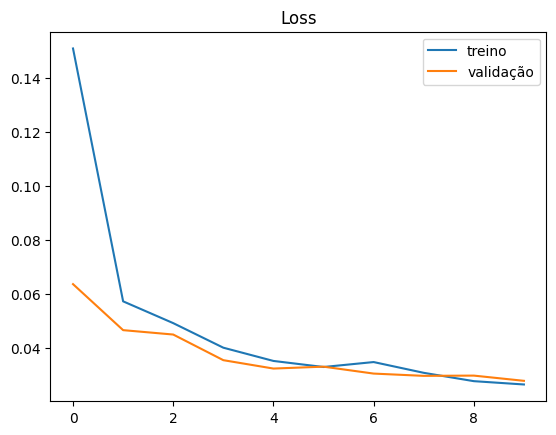

In [28]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Acurácia")
plt.legend(["treino", "validação"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["treino", "validação"])
plt.show()


## 8. Métricas Avançadas

In [29]:
val_data.reset()

pred = (model.predict(val_data) > 0.5).astype(int)
true = val_data.classes

print(confusion_matrix(true, pred))
print(classification_report(true, pred))


47/47 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step
[[150 319]
 [314 696]]
              precision    recall  f1-score   support

           0       0.32      0.32      0.32       469
           1       0.69      0.69      0.69      1010

    accuracy                           0.57      1479
   macro avg       0.50      0.50      0.50      1479
weighted avg       0.57      0.57      0.57      1479



## 9. Predição com Imagem Nova

In [40]:
def predict_image(img_path):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)[0][0]

    # probabilidade de ser cachorro
    dog_prob = float(pred)
    # probabilidade de ser gato
    cat_prob = 1.0 - dog_prob

    print("📌 Predição para:", img_path)
    print(f"🐶 Probabilidade (dog) = {dog_prob:.4f}")
    print(f"🐱 Probabilidade (cat) = {cat_prob:.4f}")

    if dog_prob > 0.5:
        print("🎯 Resultado final: 🐶 DOG")
    else:
        print("🎯 Resultado final: 🐱 CAT")


In [41]:
predict_image("/content/gato.jpg")
predict_image("/content/cachorro.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
📌 Predição para: /content/gato.jpg
🐶 Probabilidade (dog) = 0.0000
🐱 Probabilidade (cat) = 1.0000
🎯 Resultado final: 🐱 CAT
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
📌 Predição para: /content/cachorro.jpg
🐶 Probabilidade (dog) = 0.9995
🐱 Probabilidade (cat) = 0.0005
🎯 Resultado final: 🐶 DOG


In [43]:
predict_image("/content/gato1.jpg")
predict_image("/content/cachorro1.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
📌 Predição para: /content/gato1.jpg
🐶 Probabilidade (dog) = 0.0056
🐱 Probabilidade (cat) = 0.9944
🎯 Resultado final: 🐱 CAT
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
📌 Predição para: /content/cachorro1.jpg
🐶 Probabilidade (dog) = 0.9987
🐱 Probabilidade (cat) = 0.0013
🎯 Resultado final: 🐶 DOG


###

# ✔️ Conclusão

Neste projeto aplicamos Transfer Learning utilizando o modelo MobileNetV2 pré-treinado no dataset ImageNet. Organizamos o dataset Oxford-IIIT Pets em duas classes (gatos e cachorros), treinamos apenas as camadas superiores e realizamos predições com imagens externas.

Mesmo sem Fine Tuning e sem uso de class weights, o modelo apresentou alta confiança na classificação de imagens reais, demonstrando que o Transfer Learning permite bons resultados com pouco tempo de treinamento.

Etapas realizadas:
- Carregamento e preparação do dataset
- Data augmentation
- Transfer Learning com base congelada
- Treinamento com 10 epochs
- Predições com imagens externas

O próximo passo natural seria aplicar Fine Tuning para aumentar ainda mais a acurácia, mas o resultado atual já atende ao objetivo deste desafio.


